# Model Interpretability: SHAP and LIME

**Unit:** Unit 3: AI Concepts, Terminology, and Application Domains Part 2

Imagine a hospital model that reads a tumor's measurements and predicts *malignant* with 100% confidence, or a bank model that rejects a loan application. A correct prediction is not enough: the doctor must justify a biopsy, the bank is legally required to state a reason, and the engineer must check the model is not keying on a data-leak artifact. **Prediction answers "what"; explanation answers "why."** This notebook trains an accurate model, shows that accuracy alone tells us nothing about its reasoning, and then opens the box with two standard tools: SHAP and LIME.

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain why a good prediction is not enough (loan / medical framing)
- Read global feature importance three ways: impurity, SHAP mean |value|, and a beeswarm plot
- Explain a single patient's prediction with a SHAP waterfall plot
- Explain the same patient with LIME and compare the two answers
- State the difference between global and local explanations, and the honest limits of both

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 01 "Regression vs Classification" — you can now train a model that is accurate; this lesson asks whether you can explain it.

**Used later in:** Course 06 (AIAT 116) — Unit 4, which turns SHAP and LIME into an accountability requirement.

---


## 🎯 The model that would have sent asthmatics home

At KDD 2015, Rich Caruana and colleagues published *Intelligible Models for
HealthCare*. Working on a real hospital dataset, they trained models to predict
which pneumonia patients were at high risk of dying, so that low-risk patients
could be treated as outpatients. An intelligible model let them read what it had
learned, and one rule stopped them cold: **patients with a history of asthma were
predicted to have a *lower* risk of death.**

The pattern in the data was real. Asthmatic patients arriving with pneumonia were
routinely sent straight to intensive care and treated aggressively, so their
recorded outcomes were better. The model learned the *consequence of the care
they received*, and would have used it to recommend sending exactly those
patients home. A black-box model of equal accuracy would have contained the same
rule, silently.

**And explanations catch shortcuts as well as inversions.** In the paper that
introduced LIME (Ribeiro, Singh and Guestrin, 2016 — reference 1 below), the
authors deliberately trained a husky-vs-wolf classifier on images where the wolves
were photographed in snow. The model looked accurate. LIME showed it was
highlighting the **snow**, not the animal. In their user study, the proportion of
practitioners who trusted the bad classifier dropped from 10 of 27 to 3 of 27
once they saw the explanation.

### What goes wrong without an explanation

Both cases were models with good test-set scores. Accuracy could not see the
asthma rule and could not see the snow, because both patterns were genuinely
present in the training *and* the test data. Held-out evaluation catches models
that learned nothing; only inspection catches models that learned the wrong true
thing. And the two cases fail in opposite directions — one would have harmed
patients, one merely embarrassed a demo — which is why the question "what would
this model do if the world changed slightly?" cannot be answered by a number.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The scikit-learn breast cancer dataset (569 patients, 30 tumor measurements)
- `RandomForestClassifier`, `shap` (TreeExplainer), and `lime` (LimeTabularExplainer)

**Outputs:** What you'll see when you run the cells

- Test accuracy of the model, then three explanations of the same model:
  two global rankings (impurity vs SHAP), one SHAP beeswarm plot,
  one single-patient SHAP waterfall, and a LIME explanation of the same patient
- A printed table comparing SHAP's and LIME's answers side by side

---


In [1]:
# Setup: the breast-cancer dataset and a train/test split. We will train an accurate
# but opaque model, then use SHAP and LIME to open the black box.
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import shap
import lime.lime_tabular

# Real diagnostic data: 30 tumor measurements per patient, label = malignant/benign.
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

# Hold out 25% of patients; stratify keeps the class balance identical in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("=== Breast Cancer Dataset ===")
print(f"Total patients:   {X.shape[0]}  (features: {X.shape[1]})")
print(f"Training set:     {X_train.shape[0]} patients")
print(f"Test set:         {X_test.shape[0]} patients")
print(f"Classes:          0 = {data.target_names[0]}, 1 = {data.target_names[1]}")
print(f"Class counts:     malignant = {(y == 0).sum()}, benign = {(y == 1).sum()}")

=== Breast Cancer Dataset ===
Total patients:   569  (features: 30)
Training set:     426 patients
Test set:         143 patients
Classes:          0 = malignant, 1 = benign
Class counts:     malignant = 212, benign = 357


## Step 1: Baseline — A Model That Predicts Well

First the "what": we train a random forest and measure accuracy. We also pick one patient the model is very confident about — this patient will be our running example for the whole notebook. Notice what the printed output does **not** tell us: which of the 30 measurements drove the decision.

In [2]:
# Train the black box: a 100-tree random forest predicts WELL, but its output alone
# cannot say WHY a given patient was flagged — the problem interpretability tools solve.
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

accuracy = accuracy_score(y_test, rf.predict(X_test))
print("=== Prediction (the 'what') ===")
print(f"Model:         Random Forest (100 trees)")
print(f"Test accuracy: {accuracy:.3f}")

# Pick the first test patient the model is highly confident is malignant
# Pick one confidently-flagged patient to be our running 'explain this decision' example.
proba_malignant = rf.predict_proba(X_test)[:, 0]
patient_idx = int(np.argmax(proba_malignant > 0.9))
patient = X_test.iloc[patient_idx]

print(f"\n=== One patient (test row {patient_idx}) ===")
print(f"Predicted P(malignant): {proba_malignant[patient_idx]:.2f}")
print(f"True label:             {data.target_names[y_test.iloc[patient_idx]]}")
print("\nWhy did the model say malignant? The output above cannot answer that.")

=== Prediction (the 'what') ===
Model:         Random Forest (100 trees)
Test accuracy: 0.958

=== One patient (test row 1) ===
Predicted P(malignant): 1.00
True label:             malignant

Why did the model say malignant? The output above cannot answer that.


The model is right about this patient and about ~96% of the test set — but a doctor cannot order surgery, and a bank cannot send a rejection letter, on the strength of a probability alone. We need the "why."

## Step 2: Global Explanation, Baseline — Built-in Impurity Importance

Random forests ship with a free global explanation: how much each feature reduced impurity across all trees, averaged into one score per feature. This is our **baseline explanation method**. It ranks features for the model *as a whole*, but it has no sign (does a large `worst area` push toward malignant or benign?) and says nothing about any individual patient.

In [3]:
# Baseline explanation: the forest's built-in impurity importances — a quick global
# ranking, but biased toward high-cardinality features and silent about single patients.
impurity_rank = pd.Series(rf.feature_importances_, index=X.columns)
impurity_rank = impurity_rank.sort_values(ascending=False)

print("=== Baseline: impurity importance (top 5 of 30) ===")
for i, (feat, val) in enumerate(impurity_rank.head(5).items(), 1):
    print(f"{i}. {feat:<22} {val:.3f}")

=== Baseline: impurity importance (top 5 of 30) ===
1. worst area             0.150
2. worst concave points   0.127
3. mean concave points    0.105
4. worst radius           0.087
5. worst perimeter        0.080


## Step 3: Change One Thing — Measure Importance with SHAP Instead

Same model, same data — we only swap the *measuring instrument*. SHAP (SHapley Additive exPlanations) assigns every feature of every patient a signed contribution, in probability units, such that for each patient:

`base value (average P(malignant)) + sum of the 30 SHAP values = that patient's predicted P(malignant)`

`TreeExplainer` computes this exactly for tree models, and it is fast: the cell prints the wall-clock time it takes to explain the full 143-row test set (well under our 200-row budget). Averaging |SHAP value| over patients gives a global ranking we can compare directly against the impurity baseline, and the **beeswarm plot** below shows the direction that impurity importance hides: each dot is one patient, colored by feature value (red = high), placed left/right by how it pushed P(malignant).

Explained sample: 143 test patients, 30 features
SHAP computation time: 0.01 s
Base value (average P(malignant) over training data): 0.372

=== Changed instrument: SHAP mean |value| (top 5 of 30) ===
1. worst area             0.074
2. worst concave points   0.059
3. mean concave points    0.048
4. worst perimeter        0.047
5. worst radius           0.043

Top-5 overlap with impurity baseline: 5/5 features


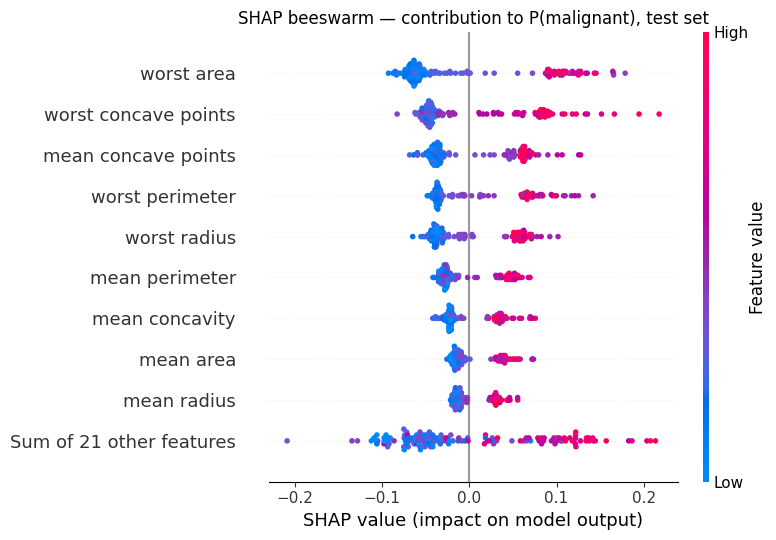

In [4]:
# SHAP assigns each feature a signed contribution that provably sums to the prediction
# (Shapley values from game theory) — here computed exactly for every test patient.
explainer = shap.TreeExplainer(rf)
X_explain = X_test  # 143 rows — small enough to explain exactly
t0 = time.perf_counter()
sv = explainer(X_explain)
shap_seconds = time.perf_counter() - t0

# Slice class 0 = malignant, so positive SHAP values push toward "malignant"
sv_malignant = sv[:, :, 0]
print(f"Explained sample: {X_explain.shape[0]} test patients, {X_explain.shape[1]} features")
print(f"SHAP computation time: {shap_seconds:.2f} s")
print(f"Base value (average P(malignant) over training data): {sv_malignant.base_values[0]:.3f}")

# Global view: average |contribution| per feature across all patients — compare with the impurity top-5.
shap_rank = pd.Series(np.abs(sv_malignant.values).mean(axis=0), index=X.columns)
shap_rank = shap_rank.sort_values(ascending=False)

print("\n=== Changed instrument: SHAP mean |value| (top 5 of 30) ===")
for i, (feat, val) in enumerate(shap_rank.head(5).items(), 1):
    print(f"{i}. {feat:<22} {val:.3f}")

overlap_global = set(impurity_rank.head(5).index) & set(shap_rank.head(5).index)
print(f"\nTop-5 overlap with impurity baseline: {len(overlap_global)}/5 features")

# Beeswarm: one dot per patient per feature; color = feature value, x = push toward malignant.
shap.plots.beeswarm(sv_malignant, max_display=10, show=False)
plt.title("SHAP beeswarm — contribution to P(malignant), test set")
plt.tight_layout()
plt.show()

**Comparing the two printed rankings:** both instruments agree on the same top-5 set (5/5 overlap) — `worst area`, `worst concave points`, `mean concave points`, `worst perimeter`, `worst radius` — and on the same #1–#3. They disagree only on the order of places 4–5: impurity puts `worst radius` (0.087) above `worst perimeter` (0.080), while SHAP swaps them (`worst perimeter` 0.047 vs `worst radius` 0.043). So for *ranking*, the change of instrument barely mattered here.

What SHAP adds is everything the baseline could not say. In the beeswarm plot, the red (high-value) dots for `worst area` and `worst concave points` sit on the **right** (positive SHAP → pushes toward malignant) and the blue (low-value) dots sit on the left: *large* tumors with *pronounced* concave points make the model predict cancer, which matches medical intuition. Impurity importance could never tell us that direction — and neither ranking can explain one specific patient. That is Step 4.

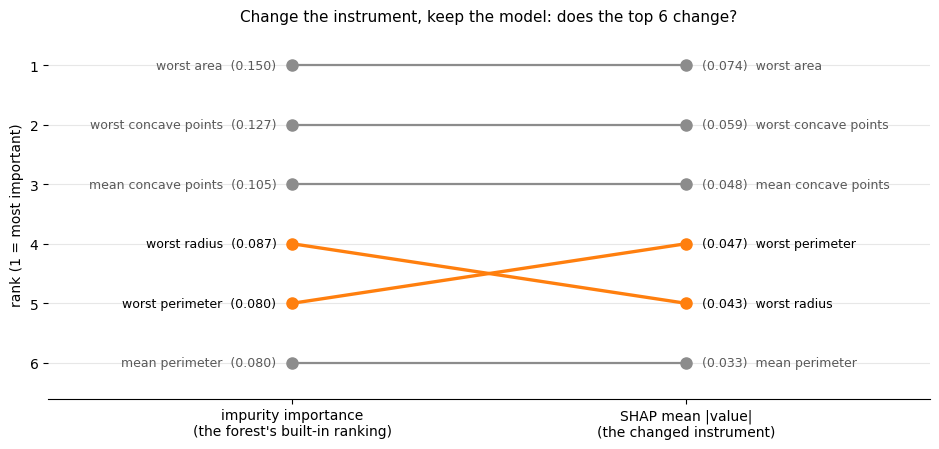

Top-5 sets: 5/5 features in common.
Top-6 sets: 6/6 in common; only on the left: none; only on the right: none.
Held the same rank (grey, flat lines): ['worst area', 'worst concave points', 'mean concave points', 'mean perimeter']
Moved (orange, sloping lines):         ['worst radius', 'worst perimeter']

A flat grey line means the two instruments put that feature in the same place.
An orange sloping line is a disagreement — and the only disagreements here are
swaps between neighbours, not a feature appearing from nowhere.


In [5]:
# The paragraph above compares two GLOBAL rankings in prose — same top-5 set, one swap
# at places 4 and 5. A ranking comparison is a shape: two columns and a line per feature.
# Lines that stay flat mean the instruments agree; lines that cross mean they do not.
import matplotlib.pyplot as plt

TOP = 6                                   # one place beyond the top-5 the text discusses
left_feats = list(impurity_rank.head(TOP).index)
right_feats = list(shap_rank.head(TOP).index)
shown = list(dict.fromkeys(left_feats + right_feats))    # union, order preserved

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for feat in shown:
    rl = left_feats.index(feat) + 1 if feat in left_feats else None
    rr = right_feats.index(feat) + 1 if feat in right_feats else None
    if rl is None or rr is None:
        continue                          # drawn as a dangling label below instead
    moved = rl != rr
    ax.plot([0, 1], [rl, rr], "-o", ms=8,
            color="tab:orange" if moved else "0.55",
            lw=2.4 if moved else 1.6, zorder=3 if moved else 2)
    ax.text(-0.04, rl, f"{feat}  ({impurity_rank[feat]:.3f})", ha="right", va="center",
            fontsize=9, color="black" if moved else "0.35")
    ax.text(1.04, rr, f"({shap_rank[feat]:.3f})  {feat}", ha="left", va="center",
            fontsize=9, color="black" if moved else "0.35")

only_left = [f for f in left_feats if f not in right_feats]
only_right = [f for f in right_feats if f not in left_feats]
ax.set_xlim(-0.62, 1.62)
ax.set_ylim(TOP + 0.6, 0.4)               # rank 1 at the top
ax.set_yticks(range(1, TOP + 1))
ax.set_ylabel("rank (1 = most important)")
ax.set_xticks([0, 1], labels=["impurity importance\n(the forest's built-in ranking)",
                              "SHAP mean |value|\n(the changed instrument)"])
ax.set_title(f"Change the instrument, keep the model: does the top {TOP} change?", fontsize=11)
ax.grid(alpha=0.3, axis="y")
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

# The claims the caption makes, as numbers.
overlap5 = set(impurity_rank.head(5).index) & set(shap_rank.head(5).index)
print(f"Top-5 sets: {len(overlap5)}/5 features in common.")
print(f"Top-{TOP} sets: {len(set(left_feats) & set(right_feats))}/{TOP} in common; "
      f"only on the left: {only_left or 'none'}; only on the right: {only_right or 'none'}.")
same_rank = [f for f in shown if f in left_feats and f in right_feats
             and left_feats.index(f) == right_feats.index(f)]
moved_rank = [f for f in shown if f in left_feats and f in right_feats
              and left_feats.index(f) != right_feats.index(f)]
print(f"Held the same rank (grey, flat lines): {same_rank}")
print(f"Moved (orange, sloping lines):         {moved_rank}")
print("\nA flat grey line means the two instruments put that feature in the same place.")
print("An orange sloping line is a disagreement — and the only disagreements here are")
print("swaps between neighbours, not a feature appearing from nowhere.")


### 📊 What to see in the figure above

**Read it as a rank ladder.** The left column is the forest's own impurity ranking, the
right column is SHAP's, and each feature is a line joining its two positions. Rank 1
is at the top of the frame. The number in brackets beside each label is that
instrument's own score, so you can see the scores as well as the places.

**Grey and flat means the two instruments agree.** The top three lines run straight
across without sloping: impurity and SHAP put the same three features in the same three
places. Given that these two methods share nothing but the model they are describing,
that is a real result and not a formality.

**Orange and sloping means they disagree — and look at how mildly.** The only lines
that tilt are neighbours trading places near the bottom of the ladder. No feature
appears in one column and vanishes from the other inside the top five; the printed lines
under the figure name exactly which features moved and which held. **So for *ranking*,
changing the instrument barely mattered here — which is precisely the sentence above,
now checkable.**

**The warning this figure cannot draw.** Agreement on the ranking is not agreement on
the answer. Impurity importance has no sign and no per-patient value: it cannot say
whether a large `worst area` pushes toward malignant or away from it, and it cannot say
anything at all about one individual. That is what the beeswarm above added and what the
waterfall below adds, and it is why the ranking agreement here is reassuring rather than
sufficient.


## Step 4: Local Explanation — Why *This* Patient? (SHAP Waterfall)

Global rankings answer "what does the model care about on average?" The doctor's question is different: "why did the model call **my patient** malignant?" The waterfall plot below reads bottom-up: start at the base value (the average P(malignant)), add this patient's signed feature contributions one by one, and land exactly on the model's prediction for this patient.

=== SHAP explanation for test patient 1 ===
Base value:              0.372
Sum of 30 SHAP values:  +0.628
= Predicted P(malignant): 1.000

Top 5 contributions (signed, probability units):
  worst area             +0.107   (patient value: 1349.00)
  worst concave points   +0.093   (patient value: 0.20)
  worst perimeter        +0.071   (patient value: 138.10)
  mean concave points    +0.063   (patient value: 0.09)
  worst radius           +0.059   (patient value: 21.08)

Context: this patient's worst area = 1349 vs dataset mean = 881


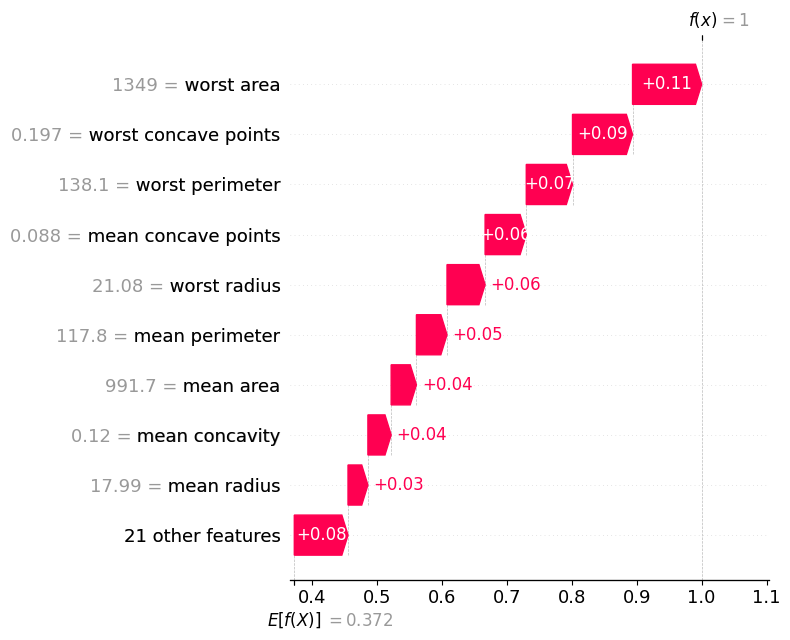

In [6]:
# Local explanation: for OUR patient, base value + 30 SHAP contributions = the model's
# exact probability — an auditable accounting of one individual decision.
patient_sv = sv_malignant[patient_idx]
contrib = pd.Series(patient_sv.values, index=X.columns)
shap_top5 = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5)

print(f"=== SHAP explanation for test patient {patient_idx} ===")
print(f"Base value:              {patient_sv.base_values:.3f}")
print(f"Sum of 30 SHAP values:  +{contrib.sum():.3f}")
print(f"= Predicted P(malignant): {patient_sv.base_values + contrib.sum():.3f}")
print("\nTop 5 contributions (signed, probability units):")
for feat, val in shap_top5.items():
    print(f"  {feat:<22} {val:+.3f}   (patient value: {patient.loc[feat]:.2f})")
print(f"\nContext: this patient's worst area = {patient.loc['worst area']:.0f}"
      f" vs dataset mean = {X['worst area'].mean():.0f}")

# Waterfall: read bottom-up how each feature pushed this patient from the base rate to the final probability.
shap.plots.waterfall(patient_sv, max_display=10, show=False)
plt.tight_layout()
plt.show()

**Reading the actual waterfall:** the model starts at the base rate P(malignant) = 0.372 and ends at 1.00 for this patient. Every top contribution is positive — `worst area` (+0.107), `worst concave points` (+0.093), `worst perimeter` (+0.071), `mean concave points` (+0.063), `worst radius` (+0.059) — a unanimous push: this tumor is large (worst area 1349 vs the printed dataset mean of 881) *and* has pronounced concave points. That sentence is an explanation a clinician can check against the scan; "P = 1.00" alone was not.

## Step 5: Change One Thing Again — Explain the Same Patient with LIME

Now we keep the model *and* the patient fixed and swap the explanation method. LIME (Local Interpretable Model-agnostic Explanations) knows nothing about trees: it generates thousands of perturbed copies of the patient, queries the model on each, and fits a small weighted linear model around the patient. Its output is a set of human-readable *rules* with weights, rather than exact additive values. If two methods with completely different mechanics point at the same features, our confidence in the explanation rises.

In [7]:
# LIME explains the same decision differently: it fits a small linear model to the
# black box NEAR this patient — rules instead of exact attributions. Compare the two answers.
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=list(X.columns),
    class_names=list(data.target_names),
    discretize_continuous=True,
    random_state=42,
)
lime_exp = lime_explainer.explain_instance(
    patient.values, rf.predict_proba, num_features=5, labels=(0,)
)
lime_pairs = lime_exp.as_list(label=0)  # weights toward class 0 = malignant

print(f"=== LIME explanation for the same patient (test row {patient_idx}) ===")
for rule, weight in lime_pairs:
    print(f"  {rule:<30} {weight:+.3f}")

# Map each LIME rule back to its base feature name (longest name that appears in the rule)
def base_feature(rule):
    return max((f for f in X.columns if f in rule), key=len)

# Side-by-side table: do SHAP and LIME even agree on which features mattered?
comparison = pd.DataFrame({
    "SHAP feature": shap_top5.index,
    "SHAP value": [f"{v:+.3f}" for v in shap_top5.values],
    "LIME rule": [r for r, _ in lime_pairs],
    "LIME weight": [f"{w:+.3f}" for _, w in lime_pairs],
}, index=pd.RangeIndex(1, 6, name="rank"))

print("\n=== SHAP vs LIME, same model, same patient ===")
print(comparison.to_string())

overlap_local = set(shap_top5.index) & {base_feature(r) for r, _ in lime_pairs}
print(f"\nTop-5 feature overlap: {len(overlap_local)}/5")

=== LIME explanation for the same patient (test row 1) ===
  worst area > 1034.25           +0.157
  worst concave points > 0.16    +0.123
  worst perimeter > 124.97       +0.110
  worst radius > 18.55           +0.087
  mean concave points > 0.07     +0.071

=== SHAP vs LIME, same model, same patient ===
              SHAP feature SHAP value                    LIME rule LIME weight
rank                                                                          
1               worst area     +0.107         worst area > 1034.25      +0.157
2     worst concave points     +0.093  worst concave points > 0.16      +0.123
3          worst perimeter     +0.071     worst perimeter > 124.97      +0.110
4      mean concave points     +0.063         worst radius > 18.55      +0.087
5             worst radius     +0.059   mean concave points > 0.07      +0.071

Top-5 feature overlap: 5/5


**Comparing the printed table:** the two methods name the **same 5 features (5/5 overlap)** and agree exactly on the top 3 — `worst area`, `worst concave points`, `worst perimeter` — with every weight positive (toward malignant) in both columns. They differ only in ranks 4–5 (SHAP: `mean concave points` then `worst radius`; LIME: `worst radius` then `mean concave points`) and in *vocabulary*: SHAP says "`worst area` contributed +0.107 probability"; LIME says "because `worst area > 1034.25`" — a threshold rule that is often easier to hand to a non-technical decision maker. Two independent instruments, one story: this prediction rests on tumor size and concavity, not on some accidental feature.

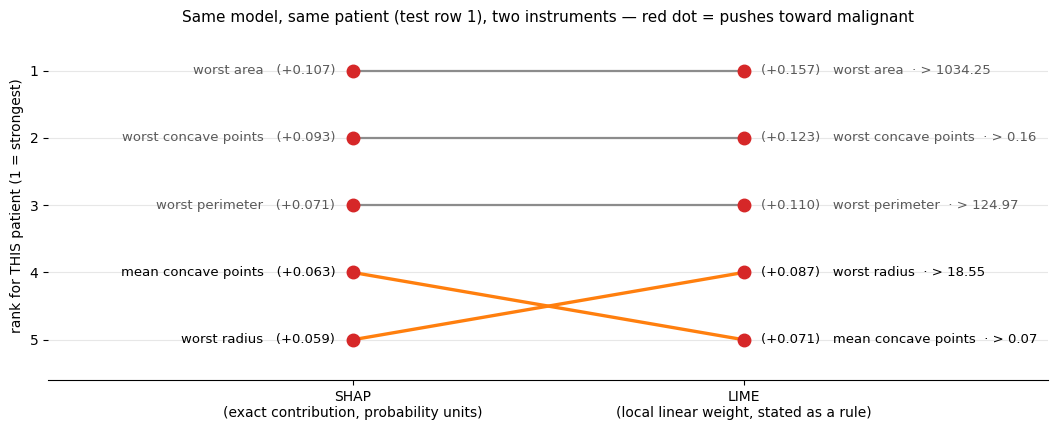

Feature sets: 5/5 in common.
SHAP order: ['worst area', 'worst concave points', 'worst perimeter', 'mean concave points', 'worst radius']
LIME order: ['worst area', 'worst concave points', 'worst perimeter', 'worst radius', 'mean concave points']
The two orders agree on the first 3 place(s) and differ from place 4.
Held the same rank (grey, flat): ['worst area', 'worst concave points', 'worst perimeter']
Moved (orange, sloping):         ['mean concave points', 'worst radius']
Every value in both columns is positive (all dots red): True

Full LIME rules, unabbreviated:
  worst area > 1034.25               +0.157
  worst concave points > 0.16        +0.123
  worst perimeter > 124.97           +0.110
  worst radius > 18.55               +0.087
  mean concave points > 0.07         +0.071

The two number columns are NOT on the same scale: a SHAP value is a slice of a
probability and the 30 of them sum to the prediction; a LIME weight is a coefficient
from a local linear fit. Compare the ORD

In [8]:
# The paragraph above is a comparison held in prose: same five features, same top three,
# different vocabulary. A comparison is a thing you look at, so draw it — as the SAME rank
# ladder used for impurity vs SHAP earlier, now with SHAP on the left and LIME on the right.
#
# WHY a ladder and not two bar charts: the waterfall above already draws this patient's SHAP
# values, and drawing them a second time would put two pictures of one thing in one notebook.
# What has NOT been drawn is the ORDER the two methods produce, which is the actual claim.
import matplotlib.pyplot as plt

shap_order = list(shap_top5.index)                       # SHAP's ranking for this patient
lime_order = [base_feature(rule) for rule, _ in lime_pairs]
lime_by_feature = {base_feature(rule): (rule, wt) for rule, wt in lime_pairs}
shown = list(dict.fromkeys(shap_order + lime_order))

fig, ax = plt.subplots(figsize=(11, 4.4))
for feat in shown:
    rl = shap_order.index(feat) + 1 if feat in shap_order else None
    rr = lime_order.index(feat) + 1 if feat in lime_order else None
    sv_v = float(shap_top5[feat]) if feat in shap_top5.index else None
    rule, wt = lime_by_feature.get(feat, (None, None))
    if rl is None or rr is None:
        # A feature only one method ranked: show it, do not hide the disagreement.
        side, r = (0, rl) if rr is None else (1, rr)
        ax.plot([side], [r], "o", ms=9, color="black")
        ax.text(side + (-0.05 if side == 0 else 0.05), r, f"{feat}  (the other method did "
                f"not rank it in its top {len(shap_order)})",
                ha="right" if side == 0 else "left", va="center", fontsize=8.5, color="black")
        continue
    moved = rl != rr
    # Red markers = this feature pushes the patient TOWARD malignant in that method.
    ax.plot([0, 1], [rl, rr], "-", color="tab:orange" if moved else "0.55",
            lw=2.4 if moved else 1.6, zorder=3 if moved else 2)
    ax.plot([0], [rl], "o", ms=9, color="tab:red" if sv_v > 0 else "tab:blue", zorder=4)
    ax.plot([1], [rr], "o", ms=9, color="tab:red" if wt > 0 else "tab:blue", zorder=4)
    ax.text(-0.045, rl, f"{feat}   ({sv_v:+.3f})", ha="right", va="center",
            fontsize=9.5, color="black" if moved else "0.35")
    short = " ".join(rule.replace(feat, "·").split())
    ax.text(1.045, rr, f"({wt:+.3f})   {feat}  {short}", ha="left", va="center",
            fontsize=9.5, color="black" if moved else "0.35")

n = len(shown)
ax.set_xlim(-0.78, 1.78)
ax.set_ylim(n + 0.6, 0.4)
ax.set_yticks(range(1, n + 1))
ax.set_ylabel("rank for THIS patient (1 = strongest)")
ax.set_xticks([0, 1], labels=["SHAP\n(exact contribution, probability units)",
                              "LIME\n(local linear weight, stated as a rule)"])
ax.set_title(f"Same model, same patient (test row {patient_idx}), two instruments — "
             "red dot = pushes toward malignant", fontsize=11)
ax.grid(alpha=0.3, axis="y")
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

# The claims the caption makes, as numbers.
overlap = set(shap_order) & set(lime_order)
print(f"Feature sets: {len(overlap)}/{len(shap_order)} in common.")
print(f"SHAP order: {shap_order}")
print(f"LIME order: {lime_order}")
k = next((i for i in range(len(shap_order)) if shap_order[i] != lime_order[i]), len(shap_order))
print(f"The two orders agree on the first {k} place(s) and differ from place {k + 1}.")
held = [f for f in overlap if shap_order.index(f) == lime_order.index(f)]
movd = [f for f in overlap if shap_order.index(f) != lime_order.index(f)]
print(f"Held the same rank (grey, flat): {held}")
print(f"Moved (orange, sloping):         {movd}")
signs = all(shap_top5[f] > 0 for f in shap_order) and all(w > 0 for _, w in lime_pairs)
print(f"Every value in both columns is positive (all dots red): {signs}")
print("\nFull LIME rules, unabbreviated:")
for rule, wt in lime_pairs:
    print(f"  {rule:<34} {wt:+.3f}")
print("\nThe two number columns are NOT on the same scale: a SHAP value is a slice of a")
print("probability and the 30 of them sum to the prediction; a LIME weight is a coefficient")
print("from a local linear fit. Compare the ORDER and the SIGN across the columns, never")
print("the magnitudes.")


### 📊 What to see in the figure above

**Same ladder as the impurity-vs-SHAP figure earlier, and that is deliberate.** Left
column is SHAP's ranking for this one patient, right column is LIME's, and each feature
is a line joining its two places. Reading the two comparisons in the same visual
language is the point: *change the instrument, keep the model, and see what survives.*

**Both columns hold the same five features.** Two methods built on completely different
ideas — exact game theory on one side, a small linear model fitted to random
perturbations around this patient on the other — reached into thirty columns and pulled
out the same five. Nothing is dangling on one side only.

**Every dot is red, in both columns.** Red means the feature pushes *this* patient
toward malignant. Not one feature argues the other way in either method, which is why
the wrap-up can say the two instruments tell one story rather than two.

**The top three lines run flat; the bottom two cross.** SHAP and LIME agree on
`worst area`, `worst concave points` and `worst perimeter`, in that order. Then they
swap the last two places — the orange crossing lines — and the printed lines under the
figure name exactly which features moved. **This is the honest picture of agreement
between explanation methods: firm at the top, wobbly at the bottom.** If your decision
depends on which feature is fourth rather than fifth, neither method is telling you what
you think it is.

**Read the right-hand labels — that is LIME's real contribution.** After the weight,
each row carries LIME's rule with `·` standing in for the feature name, so the top row
reads `worst area · > 1034.25`: *worst area above 1034.25*. SHAP hands you a number that
adds up; LIME hands you a threshold a clinician can say out loud. The full rules are
printed underneath.

**⚠️ Do not compare the two number columns as magnitudes.** A SHAP value is a piece of a
probability; a LIME weight is a local linear coefficient. Only the order and the
direction transfer between the columns.


## 💬 Discuss

Argue these against the printed evidence: **0.958** test accuracy; a 5/5 top-five
overlap between impurity and SHAP; base value **0.372** plus 30 SHAP values
summing to **P(malignant) = 1.000** for our patient, driven by `worst area`
**+0.107** at a value of 1349 against a dataset mean of 881; and LIME naming the
same five features with the rule `worst area > 1034.25`.

1. The model says malignant with probability **1.00** and both instruments agree
   on why. **Is that enough to order a biopsy?** Say what you would want that this
   notebook did not give you — and note that P = 1.00 from 100 trees means all 100
   voted the same way, not that the tumour is certainly malignant. What would you
   say to the patient?
2. SHAP reports `worst area +0.107` in probability units; LIME reports
   `worst area > 1034.25`. **Which sentence would you put in a letter to a
   patient, and which in a report to the hospital's clinical governance
   committee?** Defend both choices; they need not be the same tool.
3. Both instruments agreed 5/5 here. Suppose on the next patient they disagree —
   SHAP says texture, LIME says radius. What do you do? List, in order, the three
   things you would check before you conclude that either explanation is wrong.
4. Caruana's team caught the asthma rule because the model was intelligible by
   construction. We caught nothing here — because there was nothing to catch, or
   because we did not look in the right place? **Design the specific check you
   would run on this random forest to look for an asthma-style inversion**, using
   only what this notebook already computed.


## 🧭 Wrap-Up: Global vs Local, and Honest Limits

| Question | Scope | Tool in this notebook |
|---|---|---|
| "What does the model rely on overall?" | **Global** | Impurity importance, SHAP mean \|value\|, beeswarm |
| "Why this patient / this loan applicant?" | **Local** | SHAP waterfall, LIME rules |

Global explanations audit the model (is it using sensible features?); local explanations justify individual decisions (the doctor's and the regulator's question). You usually need both.

**Limitations — be honest about what we just did.** SHAP and LIME explain *the model*, not *reality*: they faithfully report what the random forest keys on, even if the model itself learned a spurious shortcut, and correlated features (here `worst radius`, `worst perimeter`, and `worst area` are near-duplicates of one another) split credit among themselves in ways that can shuffle rankings — exactly the ranks 4–5 disagreements we observed. LIME's answer additionally depends on its random perturbations and discretization thresholds (we fixed `random_state=42`; a different seed can reorder close features), while SHAP's additivity is exact for trees but computing it for large non-tree models requires approximation. None of these values are causal claims: "worst area pushed P(malignant) up by +0.107" describes this classifier's arithmetic, not what would happen to the patient if the tumor shrank. Explanations make models auditable — they do not make them right.

## ⚠️ Where this breaks

The wrap-up above states the honest limits; this section names them as failure
conditions you should be able to recite.

- **They explain the model, not the world.** SHAP's `+0.107` for `worst area` is
  an exact statement about this random forest's arithmetic and **not** a causal
  claim about tumours. If the model learned an asthma-style inversion, SHAP will
  faithfully explain the inversion — clearly, confidently, and wrongly about reality.
- **Correlated features split the credit arbitrarily.** `worst radius`,
  `worst perimeter` and `worst area` are near-duplicates of one another, and that
  is exactly where our two instruments disagreed (ranks 4-5). Never present a
  feature ranking over correlated inputs as if the order were meaningful.
- **SHAP's exactness is a property of tree models only.** `TreeExplainer` is exact
  and took **0.01 s** for 143 patients. `KernelExplainer` on a non-tree model is
  an approximation whose cost grows with features and background-sample size —
  minutes to hours, with a variance you must report.
- **LIME depends on choices you made.** Its perturbations are random (we fixed
  `random_state=42`) and its rules come from discretisation thresholds it picked.
  A different seed can reorder close features. **Always report the seed, or report
  a distribution over seeds.**
- **Explanations can be attacked.** Slack, Hilgard, Jia, Singh and Lakkaraju
  (*Fooling LIME and SHAP*, AIES 2020) showed that a deliberately built classifier
  can behave one way on real inputs and differently on the synthetic points these
  methods probe with — producing innocuous explanations for a biased model. An
  explanation from an adversarial supplier is not evidence.
- **A local explanation is local.** The waterfall explains *this* patient. It does
  not generalise to the next one, and averaging local explanations is not the same
  as understanding the model globally.
- **Cheaper alternative:** when the stakes are high and the data is tabular, fit
  an **intrinsically interpretable** model first — a generalised additive model
  (which is what Caruana's team used), a short decision tree, or a scorecard. If
  it is close in accuracy, you get the explanation for free and you get it exactly,
  instead of buying an approximation of an explanation afterwards.


## 📚 References

1. Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier* (LIME). KDD. <https://arxiv.org/abs/1602.04938>
2. Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS. <https://arxiv.org/abs/1705.07874>
3. Lundberg, S. M., Erion, G., Chen, H., et al. (2020). *From local explanations to global understanding with explainable AI for trees*. Nature Machine Intelligence, 2, 56–67. <https://arxiv.org/abs/1905.04610>
4. Sena, L. B. T. R., & Azevedo, F. G. (2026). *Real-Time Explanations for Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2603.29946>
5. Chen, Y., Benton, J., Radhakrishnan, A., et al. (2025). *Reasoning Models Don't Always Say What They Think*. arXiv. <https://arxiv.org/abs/2505.05410>